COE 311K Final Project Part 2 Written Part

Section 1
The bacteria population model was chosen. The equation is dN/dt = -lambda(N - Nc(t)),
with lambda = 1000 and starting population 100000. The carrying capacity changes slowly
using a sine function to represent resources changing over time.

Section 2
This problem is stiff because the bacteria react very fast but resources change slowly.
Euler Forward needs h below 0.002 to stay stable, requiring around 15000 or more steps
over 30 seconds. With h = 0.1 the solution blew up immediately. With h = 0.001 it
worked but needed a large number of steps.

Section 3
Backward Euler was used to handle the stiffness. This method is implicit, so
Newton-Raphson was needed at every step. Since the equation is linear, Newton's
method converged in about one iteration each time.

Section 4
Backward Euler stayed stable for h = 0.1, 0.5, 1.0, and 5.0. Larger step sizes had
more error but still followed the general motion of the solution. The graphs show a
fast jump at the start where the population moves near the carrying capacity, then
slower oscillation as resources change.

Section 5
Backward Euler was much cheaper than Forward Euler. Forward Euler needed about 30000
steps for the stable case, while Backward Euler needed far fewer steps depending on h.
Overall, implicit methods work better for stiff equations because they allow much
bigger step sizes and still stay stable.

[1] Anthropic, "Claude (claude-sonnet-4-6)," Large language model, 2025. [Online]. Available: https://www.anthropic.com

SECTION 2: DEMONSTRATING STIFFNESS
Euler Forward stability limit h < 0.002
Steps needed for 30 sec: 15000
Stiffness ratio: 10000
Blew up at step 5
Euler Forward with h 0.001 needs 30000 steps


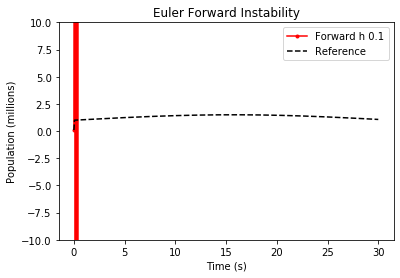

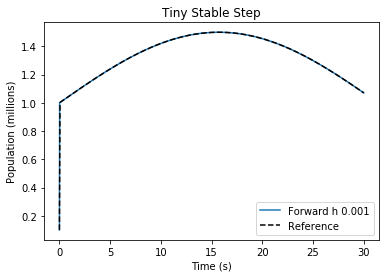


SECTION 5: RESULTS
h 0.1 steps 300 avg NR 1.0
h 0.5 steps 60 avg NR 1.0
h 1.0 steps 30 avg NR 1.0
h 5.0 steps 6 avg NR 1.0


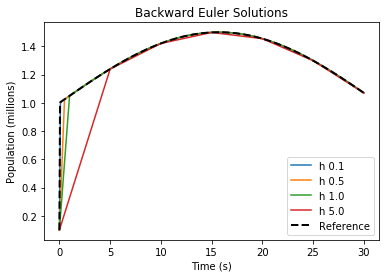

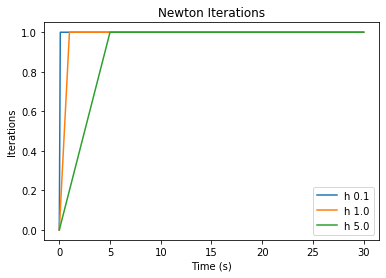

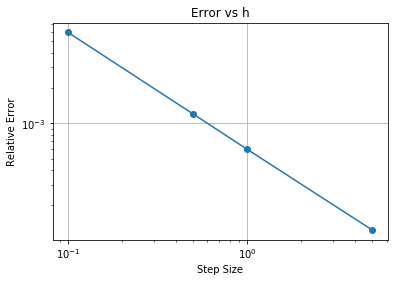


SECTION 6: PERFORMANCE
Euler Forward stable case:
h = 0.001, steps = 30000
h = 0.1 steps = 300 f evals = 600 err = 0.005940265922837512
h = 0.5 steps = 60 f evals = 120 err = 0.0011976530347745861
h = 1.0 steps = 30 f evals = 60 err = 0.0005995573174051826
h = 5.0 steps = 6 f evals = 12 err = 0.0001227799083807365


In [5]:
# COE 311K Final Project Part 2
# Option E - Population Model
# Soham Kinkhabwala

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# basic values
lam = 1000.0
N0 = 1e5
t0 = 0.0
tf = 30.0

def Ncarry(t):
    return 1e6 * (1 + 0.5*np.sin(0.1*t))

def f(t, n):
    return -lam*n + lam*Ncarry(t)


# Section 2

print("SECTION 2: DEMONSTRATING STIFFNESS")

h_lim = 2/lam
print("Euler Forward stability limit h <", round(h_lim,4))
print("Steps needed for 30 sec:", int(tf/h_lim))
print("Stiffness ratio:", int(lam/0.1))

h_big = 0.1
tt = t0
nn = N0
tbad = [t0]
nbad = [N0]

for i in range(int((tf-t0)/h_big)):
    newn = nn + h_big*f(tt, nn)
    tt = tt + h_big
    tbad.append(tt)
    nbad.append(newn)

    if abs(newn) > 1e15:
        print("Blew up at step", i+1)
        break

    nn = newn

tbad = np.array(tbad)
nbad = np.array(nbad)

h_small = 0.001
ts = np.arange(t0, tf+h_small, h_small)
ns = np.zeros(len(ts))
ns[0] = N0

for i in range(1, len(ts)):
    ns[i] = ns[i-1] + h_small*f(ts[i-1], ns[i-1])

print("Euler Forward with h 0.001 needs", len(ts)-1, "steps")

ref = solve_ivp(f, [t0, tf], [N0], method="Radau",
                dense_output=True, rtol=1e-10, atol=1e-12)

tref = np.linspace(t0, tf, 500)
nref = ref.sol(tref)[0]

# graph 1
plt.figure()
plt.plot(tbad, nbad/1e6, 'r-o', ms=3, label="Forward h 0.1")
plt.plot(tref, nref/1e6, 'k--', label="Reference")
plt.xlabel("Time (s)")
plt.ylabel("Population (millions)")
plt.title("Euler Forward Instability")
plt.legend()
plt.ylim([-10,10])
plt.show()

# graph 2
plt.figure()
plt.plot(ts[::10], ns[::10]/1e6, label="Forward h 0.001")
plt.plot(tref, nref/1e6, 'k--', label="Reference")
plt.xlabel("Time (s)")
plt.ylabel("Population (millions)")
plt.title("Tiny Stable Step")
plt.legend()
plt.show()


# backward euler functions

def g(x, old, tnext, h):
    return x - old - h*f(tnext, x)

def gp(h):
    return 1 + h*lam

def newton(old, tnext, h, tol=1e-6, maxit=20):
    x = old
    c = 0

    for j in range(maxit):
        val = g(x, old, tnext, h)

        if abs(val) < tol:
            break

        x = x - val/gp(h)
        c = c + 1

    return x, c

def backward(h, t0, tf, n0):
    t = np.arange(t0, tf+h, h)
    t = t[t <= tf + 1e-10]

    n = np.zeros(len(t))
    it = np.zeros(len(t), dtype=int)
    n[0] = n0

    for i in range(1, len(t)):
        n[i], it[i] = newton(n[i-1], t[i], h)

    return t, n, it


# Section 5

print("\nSECTION 5: RESULTS")

hs = [0.1, 0.5, 1.0, 5.0]
store = {}

for h in hs:
    t, n, it = backward(h, t0, tf, N0)
    store[h] = (t, n, it)
    print("h", h, "steps", len(t)-1, "avg NR", round(np.mean(it[1:]),2))

# graph 3
plt.figure()
for h in hs:
    t, n, it = store[h]
    plt.plot(t, n/1e6, label="h "+str(h))

plt.plot(tref, nref/1e6, 'k--', lw=2, label="Reference")
plt.xlabel("Time (s)")
plt.ylabel("Population (millions)")
plt.title("Backward Euler Solutions")
plt.legend()
plt.show()

# graph 4
plt.figure()
for h in [0.1,1.0,5.0]:
    t, n, it = store[h]
    plt.plot(t, it, label="h "+str(h))

plt.xlabel("Time (s)")
plt.ylabel("Iterations")
plt.title("Newton Iterations")
plt.legend()
plt.show()

# graph 5
hh = []
ee = []

for h in hs:
    t, n, it = store[h]
    real = ref.sol(t)[0]
    err = np.max(np.abs(n-real))/np.max(np.abs(real))
    hh.append(h)
    ee.append(err)

plt.figure()
plt.loglog(hh, ee, 'o-')
plt.xlabel("Step Size")
plt.ylabel("Relative Error")
plt.title("Error vs h")
plt.grid(True)
plt.show()


# Section 6

print("\nSECTION 6: PERFORMANCE")

print("Euler Forward stable case:")
print("h = 0.001, steps =", len(ts)-1)

for h in hs:
    t, n, it = store[h]

    steps = len(t)-1
    avg = np.mean(it[1:])
    feval = int(steps*(avg+1))

    real = ref.sol(t)[0]
    er = np.max(np.abs(n-real)) / np.max(np.abs(real))

    print("h =", h, "steps =", steps, "f evals =", feval, "err =", er)